Output will be saved to: /content 
HPA data loaded. Version: 24.0 
Saved to current directory with 300 DPI.


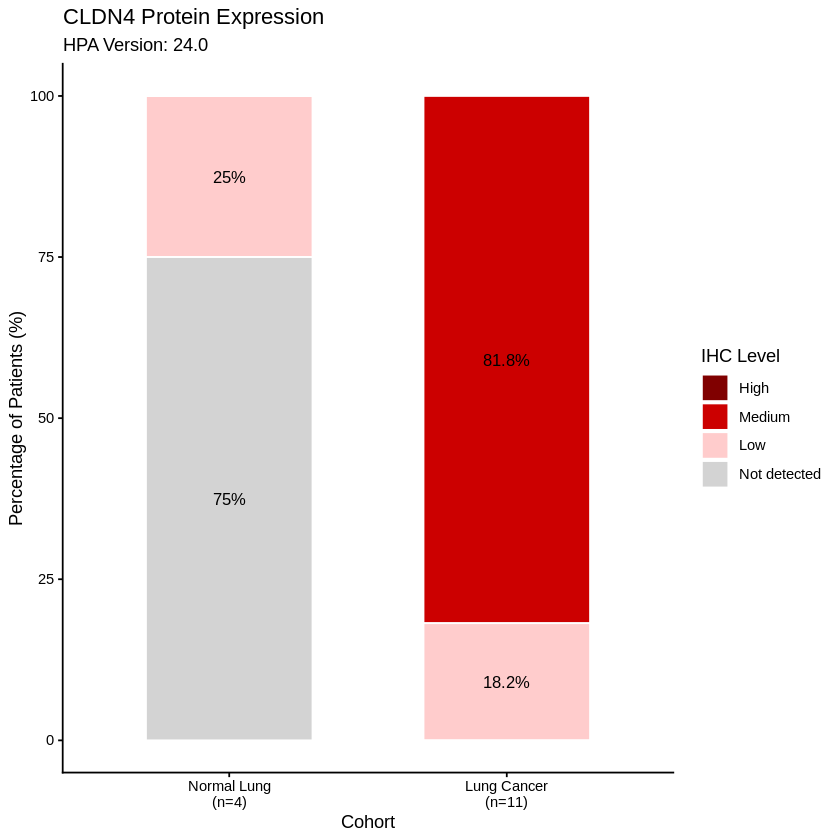

In [ ]:
## HPA version 24
# ── FIX: Manually set output directory for Notebook environment ──
OUT_DIR <- "./"
if (!dir.exists(OUT_DIR)) {
  dir.create(OUT_DIR, recursive = TRUE)
}
cat("Output will be saved to:", normalizePath(OUT_DIR), "\n")

library(HPAanalyze)
library(ggplot2)

# ── Load built-in HPA histology data ─────────────────────────────
data("hpa_histology_data")
cat("HPA data loaded. Version:", hpa_histology_data$metadata$HPAversion, "\n")

# ── Filter CLDN4 ─────────────────────────────────────────────────
cldn4_cancer <- hpa_histology_data$pathology[
  hpa_histology_data$pathology$gene == "CLDN4" &
    hpa_histology_data$pathology$cancer == "lung cancer", ]

# HPA v24 check: 'lung' tissue might not exist, using auto-detection
lung_label <- "lung"
if (!any(hpa_histology_data$normal_tissue$tissue == "lung")) {
    lung_label <- hpa_histology_data$normal_tissue$tissue[grep("lung", hpa_histology_data$normal_tissue$tissue, ignore.case=T)[1]]
}

cldn4_normal <- hpa_histology_data$normal_tissue[
  hpa_histology_data$normal_tissue$gene == "CLDN4" &
    hpa_histology_data$normal_tissue$tissue == lung_label, ]

# ── Prepare data ─────────────────────────────────────────────────
all_levels <- c("High", "Medium", "Low", "Not detected")

cancer_long <- data.frame(
  group = "Lung Cancer",
  level = all_levels,
  count = c(cldn4_cancer$high, cldn4_cancer$medium,
            cldn4_cancer$low,  cldn4_cancer$not_detected)
)

if (nrow(cldn4_normal) > 0) {
    normal_counts <- table(cldn4_normal$level)
    normal_long <- data.frame(
      group = "Normal Lung",
      level = names(normal_counts),
      count = as.integer(normal_counts)
    )
    missing <- setdiff(all_levels, normal_long$level)
    if (length(missing) > 0) {
      normal_long <- rbind(normal_long, data.frame(group = "Normal Lung", level = missing, count = 0))
    }
    df_plot <- rbind(cancer_long, normal_long)
} else {
    df_plot <- cancer_long
}

# Set group levels to place Cancer on the right
df_plot$group <- factor(df_plot$group, levels = c("Normal Lung", "Lung Cancer"))
df_plot$level <- factor(df_plot$level, levels = all_levels)
df_plot$pct <- ave(df_plot$count, df_plot$group, FUN = function(x) x / sum(x) * 100)

# ── Calculate Cohort Sizes for Labels ─────────────────────────────
sample_counts <- aggregate(count ~ group, data = df_plot, FUN = sum)
labels_with_n <- setNames(paste0(sample_counts$group, "\n(n=", sample_counts$count, ")"), sample_counts$group)

# ── Plot with requested Red-Burgundy Gradient and % Labels ───────
level_colors <- c(
    "High"         = "#800000",  # Burgundy
    "Medium"       = "#CC0000",  # Red
    "Low"          = "#FFCCCC",  # Light Pink
    "Not detected" = "#D3D3D3"   # Grey
)

p <- ggplot(df_plot, aes(x = group, y = pct, fill = level)) +
  geom_bar(stat = "identity", width = 0.6, color = "white") +
  # Add percentage labels
  geom_text(aes(label = ifelse(pct > 0, paste0(round(pct, 1), "%"), "")),
            position = position_stack(vjust = 0.5),
            color = "black",  size = 3.5) +
  scale_fill_manual(values = level_colors, name = "IHC Level") +
  scale_x_discrete(labels = labels_with_n) +
  theme_classic() +
  theme(text = element_text(family = "Arial")) + # Set font to Arial
  labs(title = "CLDN4 Protein Expression",
       subtitle = paste("HPA Version:", hpa_histology_data$metadata$HPAversion),
       x = "Cohort",
       y = "Percentage of Patients (%)")

print(p)

# Save with 300 DPI
ggsave(file.path(OUT_DIR, "cldn4_HPA_IHC_red_gradient.png"), p, width = 6, height = 5, dpi = 300)
cat("Saved to current directory with 300 DPI.\n")

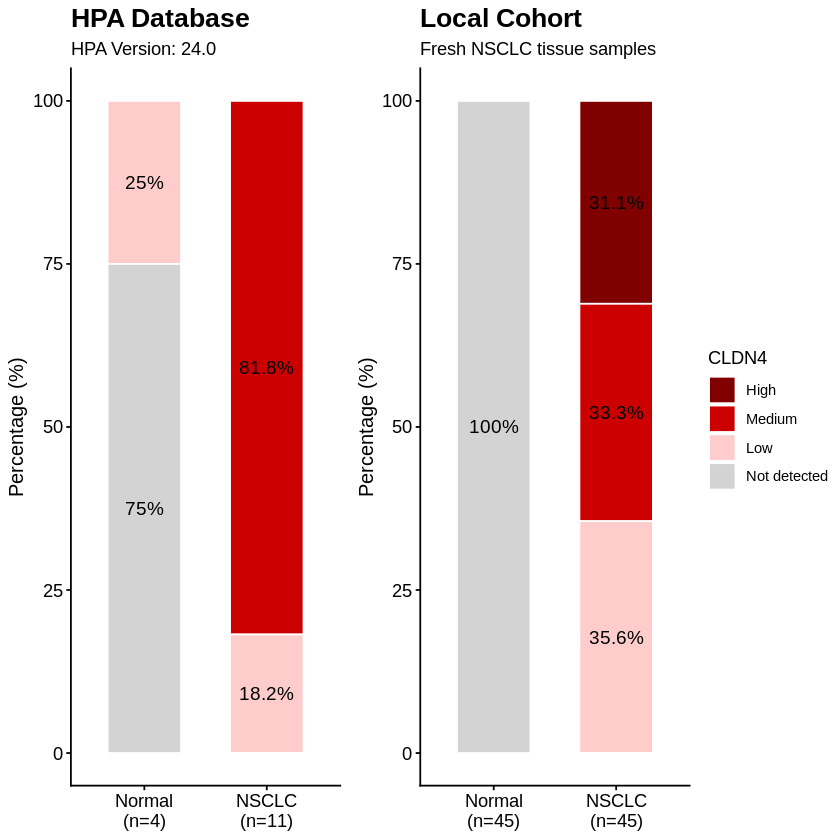

In [ ]:
if (!requireNamespace("ggpubr", quietly = TRUE)) install.packages("ggpubr")
if (!requireNamespace("svglite", quietly = TRUE)) install.packages("svglite")
library(HPAanalyze)
library(ggplot2)
library(ggpubr)

# 1. PREPARE HPA DATA
data("hpa_histology_data")
lung_label <- "lung"
if (!any(hpa_histology_data$normal_tissue$tissue == "lung")) {
    lung_label <- hpa_histology_data$normal_tissue$tissue[grep("lung", hpa_histology_data$normal_tissue$tissue, ignore.case=T)[1]]
}

cldn4_cancer_hpa <- hpa_histology_data$pathology[
  hpa_histology_data$pathology$gene == "CLDN4" & hpa_histology_data$pathology$cancer == "lung cancer", ]
cldn4_normal_hpa <- hpa_histology_data$normal_tissue[
  hpa_histology_data$normal_tissue$gene == "CLDN4" & hpa_histology_data$normal_tissue$tissue == lung_label, ]

all_levels <- c("High", "Medium", "Low", "Not detected")
level_colors <- c("High"="#800000", "Medium"="#CC0000", "Low"="#FFCCCC", "Not detected"="#D3D3D3")

# HPA Dataframe - Updated Group Names
hpa_df <- rbind(
  data.frame(group="Normal", level=all_levels, count=c(0,0,0,nrow(cldn4_normal_hpa))),
  data.frame(group="NSCLC", level=all_levels, count=c(cldn4_cancer_hpa$high, cldn4_cancer_hpa$medium, cldn4_cancer_hpa$low, cldn4_cancer_hpa$not_detected))
)

if(nrow(cldn4_normal_hpa) > 0){
  norm_tab <- table(factor(cldn4_normal_hpa$level, levels=all_levels))
  hpa_df[hpa_df$group == "Normal", "count"] <- as.numeric(norm_tab)
}

hpa_df$pct <- ave(hpa_df$count, hpa_df$group, FUN = function(x) x / sum(x) * 100)
hpa_df$group <- factor(hpa_df$group, levels = c("Normal", "NSCLC"))
hpa_df$level <- factor(hpa_df$level, levels = all_levels)

# 2. PREPARE LOCAL DATA - Updated Group Names
local_df <- rbind(
  data.frame(group="Normal", level=all_levels, count=c(0, 0, 0, 45)),
  data.frame(group="NSCLC", level=all_levels, count=c(14, 15, 16, 0))
)
local_df$pct <- ave(local_df$count, local_df$group, FUN = function(x) x / sum(x) * 100)
local_df$group <- factor(local_df$group, levels = c("Normal", "NSCLC"))
local_df$level <- factor(local_df$level, levels = all_levels)

get_labels <- function(df) {
  s <- aggregate(count ~ group, data = df, FUN = sum)
  setNames(paste0(s$group, "\n(n=", s$count, ")"), s$group)
}

make_plot <- function(df, title, subtitle) {
  ggplot(df, aes(x = group, y = pct, fill = level)) +
    geom_bar(stat = "identity", width = 0.6, color = "white") +
    geom_text(aes(label = ifelse(pct > 0, paste0(round(pct, 1), "%"), "")),
              position = position_stack(vjust = 0.5), color = "black", size = 4) +
    scale_fill_manual(values = level_colors, name = "CLDN4") +
    scale_x_discrete(labels = get_labels(df)) +
    theme_classic() +
    theme(text = element_text(family = "Helvetica"),
          plot.title = element_text(face="bold", size=16),
          axis.title = element_text(size=12),
          axis.text = element_text(size=11)) +
    labs(title = title, subtitle = subtitle, x = NULL, y = "Percentage (%)")
}

p_hpa <- make_plot(hpa_df, "HPA Database", paste("HPA Version:", hpa_histology_data$metadata$HPAversion))
p_local <- make_plot(local_df, "Local Cohort", "Fresh NSCLC tissue samples")

# Combine with common legend on the right
combined_plot <- ggarrange(p_hpa, p_local, ncol = 2, common.legend = TRUE, legend = "right")

# Save in PNG and SVG
ggsave("CLDN4_Comparison_Plot_v2.png", combined_plot, width = 12, height = 7.2, dpi = 300)
ggsave("CLDN4_Comparison_Plot_v2.svg", combined_plot, width = 12, height = 7.2)
print(combined_plot)